# EDA — Phase 3

Exploratory pass on `data/interim/swiggy_cleaned.csv`. Lightweight and informal — not a pipeline stage. Plots only, no conclusions drawn here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/interim/swiggy_cleaned.csv", parse_dates=["order_datetime"])
df.shape

Matplotlib is building the font cache; this may take a moment.


(41953, 21)

## 1. Target distribution — `Time_taken(min)`

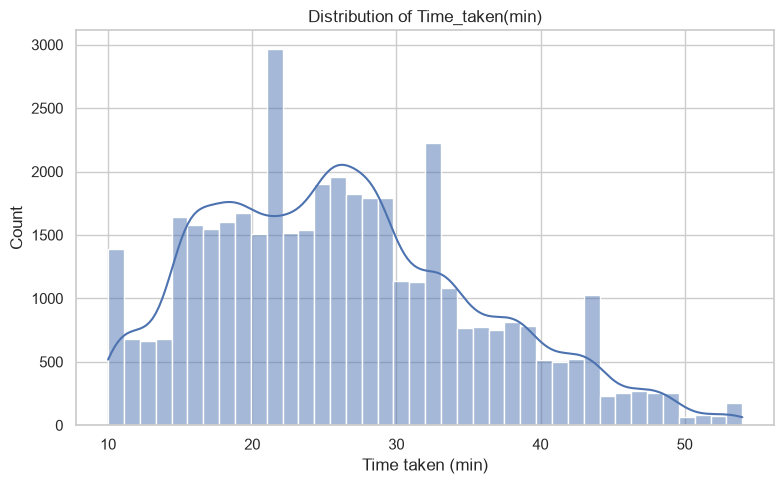

np.float64(0.4818810515707128)

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["Time_taken(min)"], bins=40, kde=True, ax=ax)
ax.set_title("Distribution of Time_taken(min)")
ax.set_xlabel("Time taken (min)")
plt.tight_layout()
plt.show()

df["Time_taken(min)"].skew()

## 2. `distance_km` vs `Time_taken(min)`

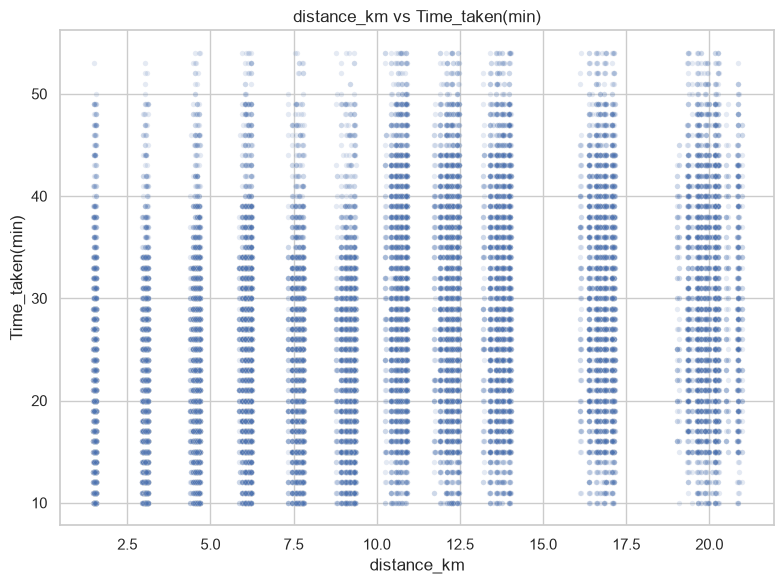

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="distance_km", y="Time_taken(min)", alpha=0.15, s=15, ax=ax)
ax.set_title("distance_km vs Time_taken(min)")
plt.tight_layout()
plt.show()

## 3. `Time_taken(min)` by categorical columns

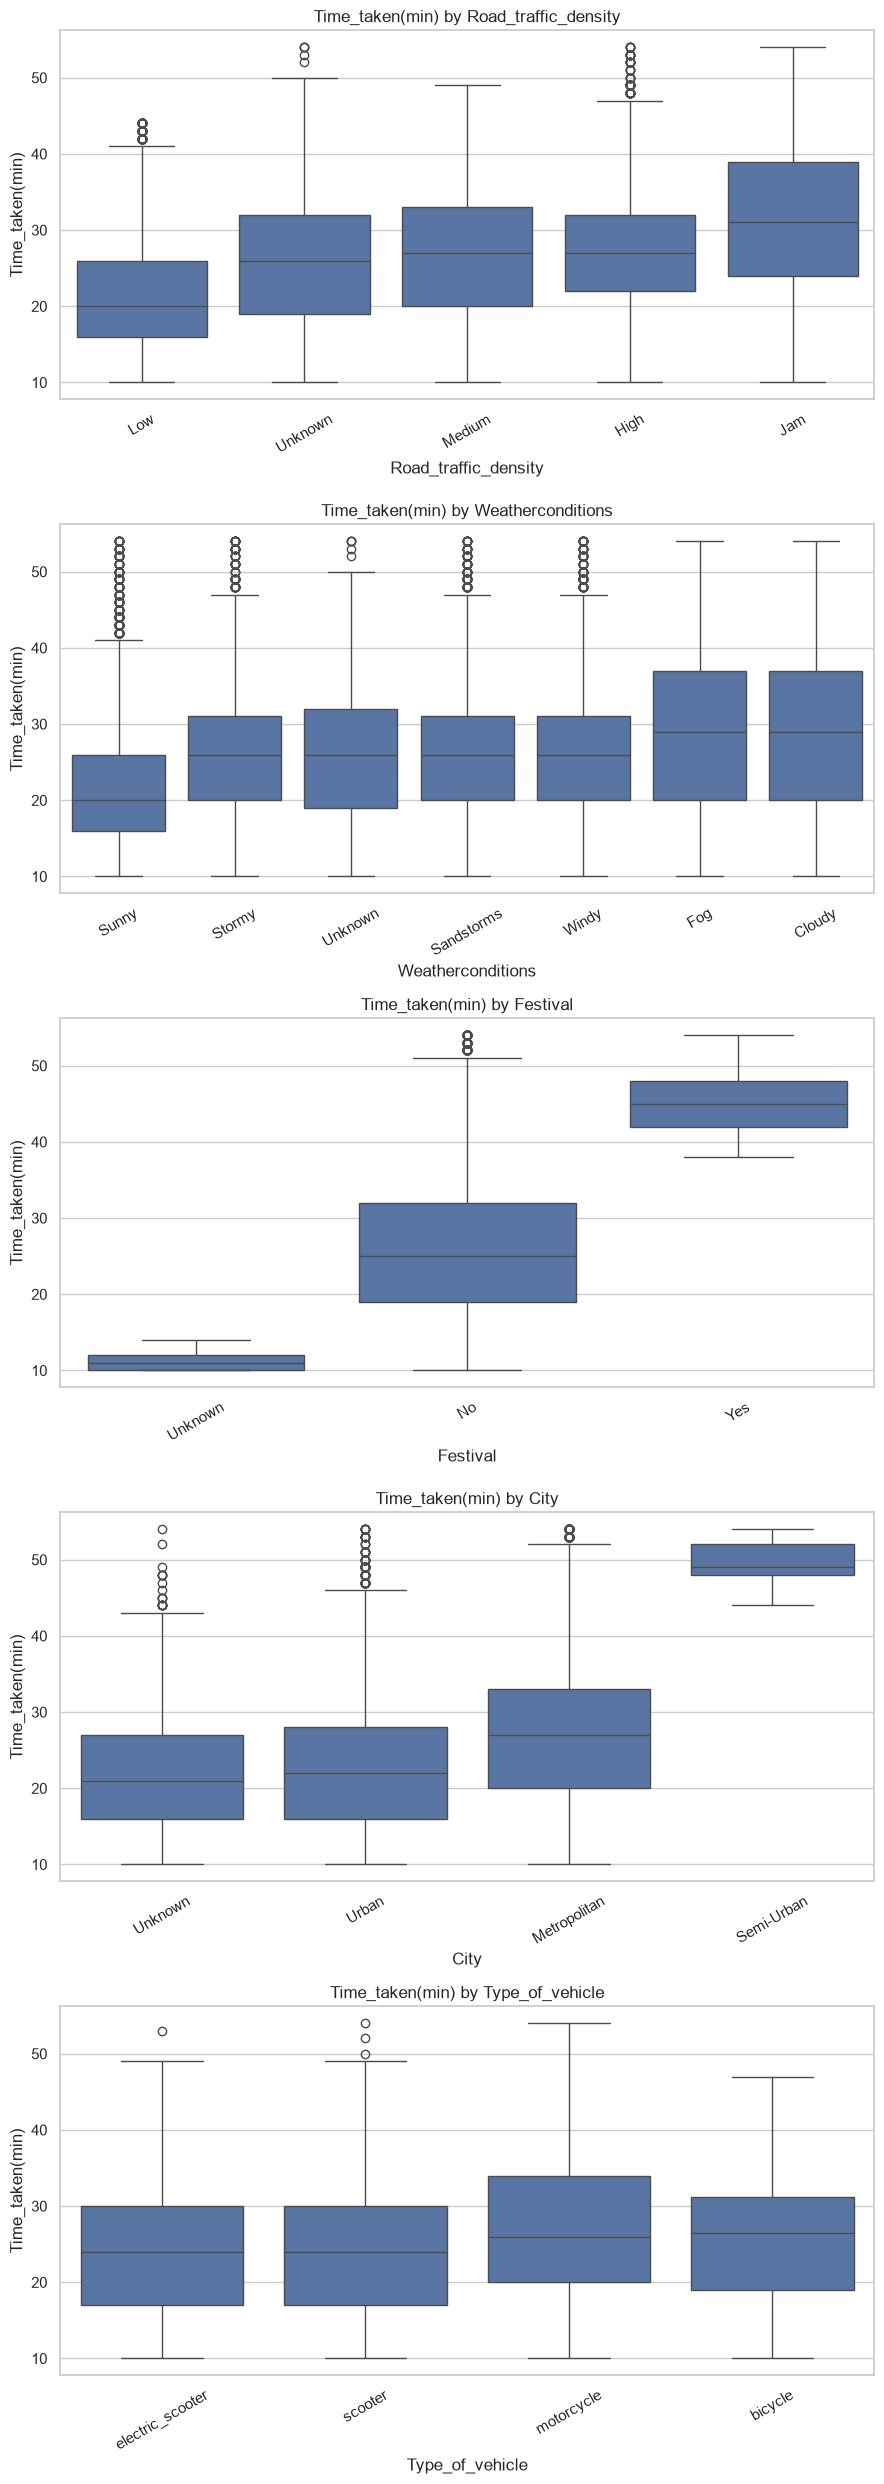

In [4]:
group_cols = ["Road_traffic_density", "Weatherconditions", "Festival", "City", "Type_of_vehicle"]

fig, axes = plt.subplots(len(group_cols), 1, figsize=(9, 5 * len(group_cols)))
for ax, col in zip(axes, group_cols):
    order = df.groupby(col)["Time_taken(min)"].median().sort_values().index
    sns.boxplot(data=df, x=col, y="Time_taken(min)", order=order, ax=ax)
    ax.set_title(f"Time_taken(min) by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 4. Correlation of `Delivery_person_Age` / `Delivery_person_Ratings` with target

(Missing values in these two columns are expected here — imputation is deferred to Phase 4. `pandas.corr()` drops NaNs pairwise by default.)

Delivery_person_Age        0.298550
Delivery_person_Ratings   -0.342681
Time_taken(min)            1.000000
Name: Time_taken(min), dtype: float64


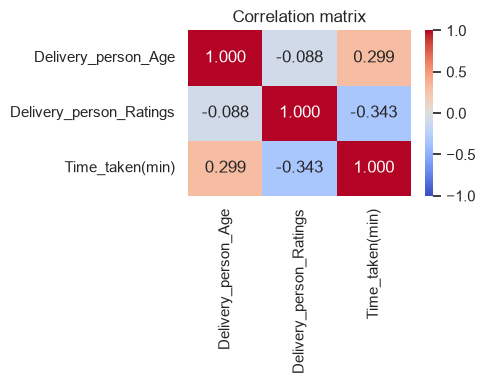

In [5]:
corr_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Time_taken(min)"]
corr = df[corr_cols].corr()
print(corr["Time_taken(min)"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## 5. `order_hour` vs average `Time_taken(min)`

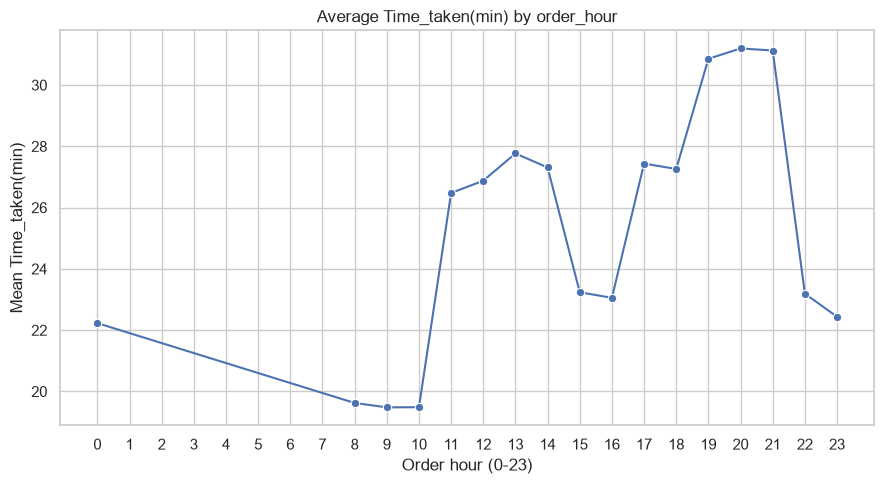

,mean,count
order_hour,,
0,22.228916,415
8,19.623213,1749
9,19.481363,1878
10,19.484367,1887
11,26.477748,1865
12,26.876744,860
13,27.766043,748
14,27.308201,756
15,23.237064,831


In [6]:
hourly = df.groupby("order_hour")["Time_taken(min)"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=hourly.index, y=hourly["mean"], marker="o", ax=ax)
ax.set_title("Average Time_taken(min) by order_hour")
ax.set_xlabel("Order hour (0-23)")
ax.set_ylabel("Mean Time_taken(min)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

hourly